In [58]:
import numpy as np
import matplotlib.pyplot as plt


In [82]:
users = []
movies = []
ratings = []
with open("movieLense-100k/ratings.csv") as f:
    for line in f:
        temp = (line.strip().split(","))
        users.append(temp[0])
        movies.append(temp[1])
        ratings.append(temp[2])

users.pop(0)
movies.pop(0)
ratings.pop(0)
print(len(users))
print(len(movies))
print(len(ratings))

print(f"{len(users)} x {len(movies)}")

100836
100836
100836
100836 x 100836


In [83]:
users = np.array(users)
movies = np.array(movies)
ratings = np.array(ratings)

In [84]:
users = users.astype(int)
movies = movies.astype(int)
ratings = ratings.astype(float)

In [85]:
np.random.seed(67)

In [86]:
users = users.astype(int)
movies = movies.astype(int)
ratings = ratings.astype(float)

unique_users = np.unique(users)
unique_movies = np.unique(movies)

user_to_idx = {user_id: idx for idx, user_id in enumerate(unique_users)}
movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(unique_movies)}

users = np.array([user_to_idx[u] for u in users])
movies = np.array([movie_to_idx[m] for m in movies])

In [87]:
num_examples = len(users)
indices = np.arange(num_examples)
np.random.shuffle(indices)

train_end = int(0.70 * num_examples)
val_end = int(0.90 * num_examples)

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]

train_users = users[train_indices]
train_movies = movies[train_indices]
train_ratings = ratings[train_indices]

val_users = users[val_indices]
val_movies = movies[val_indices]
val_ratings = ratings[val_indices]

test_users = users[test_indices]
test_movies = movies[test_indices]
test_ratings = ratings[test_indices]

print(len(train_ratings), len(val_ratings), len(test_ratings))

70585 20167 10084


In [88]:
r = 50
A = np.random.normal(0, 0.1, size=(len(users), r))
B = np.random.normal(0, 0.1, size=(len(movies), r))

In [89]:
def predict(user_ids, movie_ids, A, B):
    return np.sum(A[user_ids] * B[movie_ids], axis=1)

In [90]:
def rmse(user_ids, movie_ids, true_ratings, A, B):
    preds = predict(user_ids, movie_ids, A, B)
    return np.sqrt(np.mean((true_ratings - preds) ** 2))

In [91]:
learning_rate = 0.01
regularization = 0.02
epochs = 30

for epoch in range(epochs):
    # Shuffle training examples each epoch
    order = np.arange(len(train_ratings))
    np.random.shuffle(order)

    for idx in order:
        u = train_users[idx]
        m = train_movies[idx]
        rating = train_ratings[idx]

        pred = np.dot(A[u], B[m])
        error = rating - pred

        # Save copies before update
        A_old = A[u].copy()
        B_old = B[m].copy()

        # Gradient updates
        A[u] += learning_rate * (error * B_old - regularization * A_old)
        B[m] += learning_rate * (error * A_old - regularization * B_old)

    train_rmse = rmse(train_users, train_movies, train_ratings, A, B)
    val_rmse = rmse(val_users, val_movies, val_ratings, A, B)

    print(f"Epoch {epoch+1}: train RMSE = {train_rmse:.4f}, val RMSE = {val_rmse:.4f}")

Epoch 1: train RMSE = 3.2298, val RMSE = 3.2914
Epoch 2: train RMSE = 1.7622, val RMSE = 1.9291
Epoch 3: train RMSE = 1.3054, val RMSE = 1.5497
Epoch 4: train RMSE = 1.0851, val RMSE = 1.3960
Epoch 5: train RMSE = 0.9508, val RMSE = 1.3181
Epoch 6: train RMSE = 0.8604, val RMSE = 1.2729
Epoch 7: train RMSE = 0.7929, val RMSE = 1.2449
Epoch 8: train RMSE = 0.7414, val RMSE = 1.2292
Epoch 9: train RMSE = 0.6982, val RMSE = 1.2158
Epoch 10: train RMSE = 0.6604, val RMSE = 1.2080
Epoch 11: train RMSE = 0.6266, val RMSE = 1.2011
Epoch 12: train RMSE = 0.5963, val RMSE = 1.1979
Epoch 13: train RMSE = 0.5690, val RMSE = 1.1962
Epoch 14: train RMSE = 0.5430, val RMSE = 1.1933
Epoch 15: train RMSE = 0.5204, val RMSE = 1.1923
Epoch 16: train RMSE = 0.4984, val RMSE = 1.1909
Epoch 17: train RMSE = 0.4787, val RMSE = 1.1917
Epoch 18: train RMSE = 0.4607, val RMSE = 1.1926
Epoch 19: train RMSE = 0.4437, val RMSE = 1.1918
Epoch 20: train RMSE = 0.4268, val RMSE = 1.1932
Epoch 21: train RMSE = 0.4132

In [92]:
test_rmse = rmse(test_users, test_movies, test_ratings, A, B)
print("Test RMSE:", test_rmse)

Test RMSE: 1.1907580628467918


In [93]:
raw_user_id = 1
raw_movie_id = 50

u = user_to_idx[raw_user_id]
m = movie_to_idx[raw_movie_id]

predicted_rating = np.dot(A[u], B[m])
predicted_rating = np.clip(predicted_rating, 1, 5)
print(predicted_rating) # real value of 5.0. Half a star off

4.434811625461317


In [94]:
raw_user_id = 6
raw_movie_id = 46

u = user_to_idx[raw_user_id]
m = movie_to_idx[raw_movie_id]

predicted_rating = np.dot(A[u], B[m])
predicted_rating = np.clip(predicted_rating, 1, 5)
print(predicted_rating) # real value of 4.0. It is preety close

3.9413559466463752


In [95]:
def predict(user_ids, movie_ids, A, B):
    return np.sum(A[user_ids] * B[movie_ids], axis=1)

def rmse(user_ids, movie_ids, true_ratings, A, B):
    preds = predict(user_ids, movie_ids, A, B)
    return np.sqrt(np.mean((true_ratings - preds) ** 2))

def train_matrix_factorization(
    r,
    num_users,
    num_movies,
    train_users,
    train_movies,
    train_ratings,
    val_users,
    val_movies,
    val_ratings,
    learning_rate=0.01,
    regularization=0.02,
    epochs=30,
    seed=42
):
    np.random.seed(seed)

    A = np.random.normal(0, 0.1, size=(num_users, r))
    B = np.random.normal(0, 0.1, size=(num_movies, r))

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        order = np.arange(len(train_ratings))
        np.random.shuffle(order)

        for idx in order:
            u = train_users[idx]
            m = train_movies[idx]
            rating = train_ratings[idx]

            pred = np.dot(A[u], B[m])
            error = rating - pred

            A_old = A[u].copy()
            B_old = B[m].copy()

            A[u] += learning_rate * (error * B_old - regularization * A_old)
            B[m] += learning_rate * (error * A_old - regularization * B_old)

        train_rmse = rmse(train_users, train_movies, train_ratings, A, B)
        val_rmse = rmse(val_users, val_movies, val_ratings, A, B)

        train_losses.append(train_rmse)
        val_losses.append(val_rmse)

        print(
            f"r={r}, epoch={epoch+1}, "
            f"train RMSE={train_rmse:.4f}, val RMSE={val_rmse:.4f}"
        )

    return A, B, train_losses, val_losses

In [ ]:
r_values = [2, 5, 10, 20, 50, 100]

results = {}

for r in r_values:
    A, B, train_losses, val_losses = train_matrix_factorization(
        r=r,
        num_users=len(users),
        num_movies=len(movies),
        train_users=train_users,
        train_movies=train_movies,
        train_ratings=train_ratings,
        val_users=val_users,
        val_movies=val_movies,
        val_ratings=val_ratings,
        learning_rate=0.01,
        regularization=0.02,
        epochs=30
    )

    results[r] = {
        "A": A,
        "B": B,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

r=2, epoch=1, train RMSE=3.6390, val RMSE=3.6496
r=2, epoch=2, train RMSE=2.3569, val RMSE=2.4286
r=2, epoch=3, train RMSE=1.5571, val RMSE=1.7032
r=2, epoch=4, train RMSE=1.2639, val RMSE=1.4603
r=2, epoch=5, train RMSE=1.1121, val RMSE=1.3467
r=2, epoch=6, train RMSE=1.0199, val RMSE=1.2832
r=2, epoch=7, train RMSE=0.9580, val RMSE=1.2438
r=2, epoch=8, train RMSE=0.9155, val RMSE=1.2201
r=2, epoch=9, train RMSE=0.8832, val RMSE=1.2006
r=2, epoch=10, train RMSE=0.8580, val RMSE=1.1893
r=2, epoch=11, train RMSE=0.8396, val RMSE=1.1806
r=2, epoch=12, train RMSE=0.8243, val RMSE=1.1725
r=2, epoch=13, train RMSE=0.8123, val RMSE=1.1669
r=2, epoch=14, train RMSE=0.8016, val RMSE=1.1626
r=2, epoch=15, train RMSE=0.7933, val RMSE=1.1595
r=2, epoch=16, train RMSE=0.7875, val RMSE=1.1573
r=2, epoch=17, train RMSE=0.7806, val RMSE=1.1554
r=2, epoch=18, train RMSE=0.7768, val RMSE=1.1543
r=2, epoch=19, train RMSE=0.7705, val RMSE=1.1523
r=2, epoch=20, train RMSE=0.7676, val RMSE=1.1504
r=2, epoc

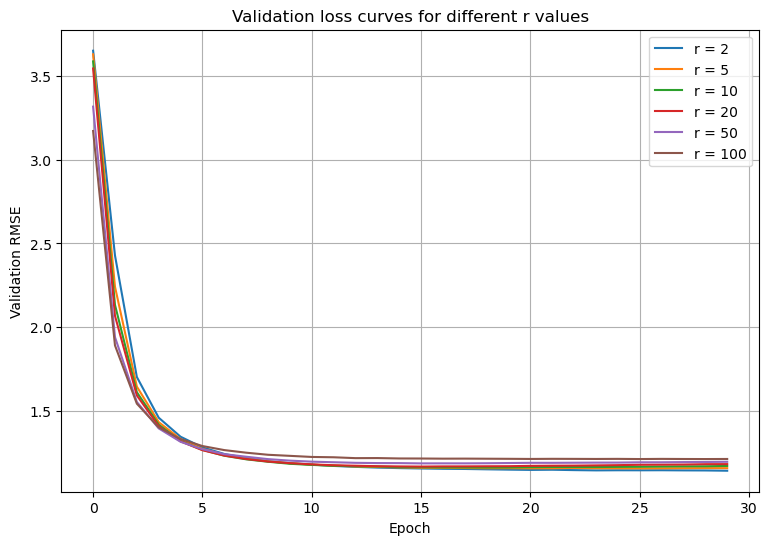

In [97]:
plt.figure(figsize=(9, 6))

for r in r_values:
    plt.plot(results[r]["val_losses"], label=f"r = {r}")

plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")
plt.title("Validation loss curves for different r values")
plt.legend()
plt.grid(True)
plt.show()

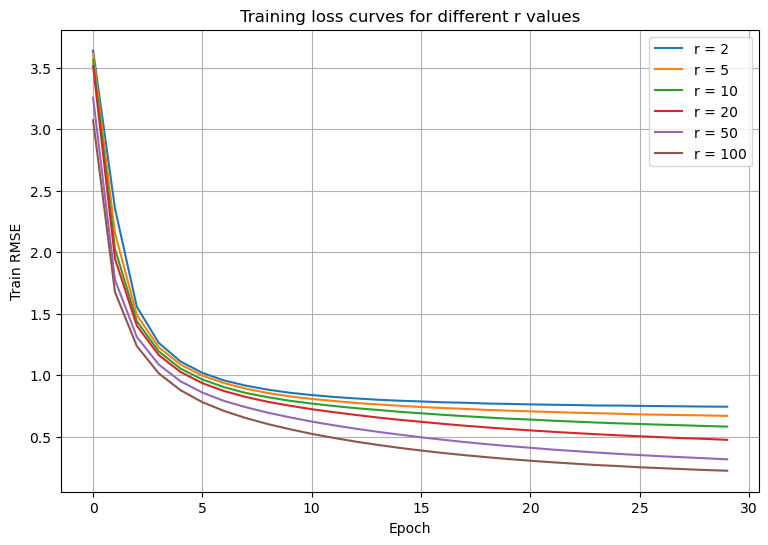

In [98]:
plt.figure(figsize=(9, 6))

for r in r_values:
    plt.plot(results[r]["train_losses"], label=f"r = {r}")

plt.xlabel("Epoch")
plt.ylabel("Train RMSE")
plt.title("Training loss curves for different r values")
plt.legend()
plt.grid(True)
plt.show()

In [99]:
def predict(user_ids, movie_ids, A, B):
    return np.sum(A[user_ids] * B[movie_ids], axis=1)

def rmse(user_ids, movie_ids, true_ratings, A, B):
    preds = predict(user_ids, movie_ids, A, B)
    return np.sqrt(np.mean((true_ratings - preds) ** 2))

def mae(user_ids, movie_ids, true_ratings, A, B):
    preds = predict(user_ids, movie_ids, A, B)
    return np.mean(np.abs(true_ratings - preds))

In [102]:
for r in r_values:
    A = results[r]["A"]
    B = results[r]["B"]

    test_rmse = rmse(test_users, test_movies, test_ratings, A, B)
    test_mae = mae(test_users, test_movies, test_ratings, A, B)

    print(
        f"r={r} | "
        f"RMSE={test_rmse:.4f} | "
        f"MAE={test_mae:.4f} | "
    )

r=2 | RMSE=1.1342 | MAE=0.7974 | 
r=5 | RMSE=1.1501 | MAE=0.8126 | 
r=10 | RMSE=1.1633 | MAE=0.8259 | 
r=20 | RMSE=1.1770 | MAE=0.8354 | 
r=50 | RMSE=1.1884 | MAE=0.8531 | 
r=100 | RMSE=1.2075 | MAE=0.8764 | 
